# Microstrip Modes

This notebook builds a simple boxed microstrip cross-section (substrate + air + PEC strip conductor), solves eigenmodes with `WaveguideModeSolver`, and plots the first fields.

In [1]:
from palacetoolkit.mode_solver import WaveguideModeSolver
from palacetoolkit.viz import view_mesh

import importlib
import inspect

import gmsh
import matplotlib.pyplot as plt
import numpy as np
import palacetoolkit.utils as ptk_utils

importlib.reload(ptk_utils)
view_fe_mesh_2d = ptk_utils.view_fe_mesh_2d
view_fields_2d = ptk_utils.view_fields_2d
write_and_finalize_gmsh = ptk_utils.write_and_finalize_gmsh

In [2]:
sig = inspect.signature(WaveguideModeSolver.__init__)
print("WaveguideModeSolver.__init__ signature:")
print(sig)
print("\nPEC conductor support via boundary attributes:", "pec_bdr" in sig.parameters)
print("The solver enforces PEC by essential DOF elimination on selected boundary attributes.")

WaveguideModeSolver.__init__ signature:
(self, mesh, order=1, mu_inv=1.0, eps=1.0, pec_bdr='all')

PEC conductor support via boundary attributes: True
The solver enforces PEC by essential DOF elimination on selected boundary attributes.


In [3]:
def make_microstrip_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    strip_w=1.8,
    strip_t=0.06,
    lc_bulk=0.18,
    lc_strip=0.05,
    meshsize=1.0,
    filename=None,
):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("microstrip_modes")

    sub = gmsh.model.occ.addRectangle(-box_w / 2, -h_sub, 0, box_w, h_sub)
    air = gmsh.model.occ.addRectangle(-box_w / 2, 0.0, 0, box_w, h_air)
    strip = gmsh.model.occ.addRectangle(-strip_w / 2, 0.0, 0, strip_w, strip_t)

    _, outmap = gmsh.model.occ.fragment([(2, sub), (2, air), (2, strip)], [])
    strip_parts = list(outmap[2])
    gmsh.model.occ.remove(strip_parts, recursive=True)
    gmsh.model.occ.synchronize()

    all_surfs = [t for _, t in gmsh.model.getEntities(2)]
    substrate_surfs = []
    air_surfs = []
    for tag in all_surfs:
        _, cy, _ = gmsh.model.occ.getCenterOfMass(2, tag)
        if cy < -1e-9:
            substrate_surfs.append(tag)
        else:
            air_surfs.append(tag)

    if not substrate_surfs or not air_surfs:
        gmsh.finalize()
        raise RuntimeError("Failed to classify substrate/air surfaces for microstrip mesh")

    gmsh.model.addPhysicalGroup(2, substrate_surfs, tag=1, name="substrate")
    gmsh.model.addPhysicalGroup(2, air_surfs, tag=2, name="air")

    bnd = gmsh.model.getBoundary([(2, t) for t in substrate_surfs + air_surfs], oriented=False, combined=False)
    edge_tags = sorted({abs(t) for _, t in bnd})

    strip_edges = []
    ground_edges = []
    open_edges = []

    for et in edge_tags:
        ex, ey, _ = gmsh.model.occ.getCenterOfMass(1, et)
        on_strip_x = abs(ex) <= strip_w / 2 + 1e-6
        on_strip_y = (-1e-6 <= ey <= strip_t + 1e-6)
        if on_strip_x and on_strip_y:
            strip_edges.append(et)
            continue

        # Ground plane is the lower boundary of the simulation box.
        if abs(ey + h_sub) <= 1e-6:
            ground_edges.append(et)
        else:
            open_edges.append(et)

    if ground_edges:
        gmsh.model.addPhysicalGroup(1, ground_edges, tag=1, name="ground_plane")
    if strip_edges:
        gmsh.model.addPhysicalGroup(1, strip_edges, tag=2, name="strip_conductor")
    if open_edges:
        gmsh.model.addPhysicalGroup(1, open_edges, tag=3, name="open_boundary")

    if meshsize <= 0:
        gmsh.finalize()
        raise ValueError("meshsize must be positive")

    lc_bulk_eff = lc_bulk * meshsize
    lc_strip_eff = lc_strip * meshsize

    # Use a distance-based field from all curves so refinement occurs
    # near any geometry boundary (PEC and domain boundaries).
    all_curves = sorted({t for _, t in gmsh.model.getEntities(1)})
    dist_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(dist_field, "CurvesList", all_curves)
    gmsh.model.mesh.field.setNumber(dist_field, "Sampling", 200)

    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "InField", dist_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMin", lc_strip_eff)
    gmsh.model.mesh.field.setNumber(threshold_field, "SizeMax", lc_bulk_eff)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", 0.0)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", 0.35 * h_sub)

    gmsh.model.mesh.field.setAsBackgroundMesh(threshold_field)
    gmsh.option.setNumber("Mesh.CharacteristicLengthFromPoints", 0)
    gmsh.option.setNumber("Mesh.CharacteristicLengthFromCurvature", 0)
    gmsh.option.setNumber("Mesh.CharacteristicLengthExtendFromBoundary", 0)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", lc_strip_eff)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc_bulk_eff)

    gmsh.model.mesh.generate(2)
    return write_and_finalize_gmsh(filename, prefix="wg_microstrip_")

In [4]:
eps_sub = 4.8
eps_air = 1.0
mu_r = 1.0

omega = 1.0
kn_air = omega * np.sqrt(mu_r * eps_air)
kn_sub = omega * np.sqrt(mu_r * eps_sub)
print(f"Reference phase window (air to substrate): {kn_air:.4f} < kn < {kn_sub:.4f}")

Reference phase window (air to substrate): 1.0000 < kn < 2.1909


Loading mesh file: /tmp/wg_microstrip_ftoylzts.msh
Groups to render transparent: ['air_none', 'air_plastic_enclosure']

Mesh loaded successfully with 2 cell blocks
Found 5778 triangles total
Physical group tags in mesh: {1: 'substrate', 2: 'air'}



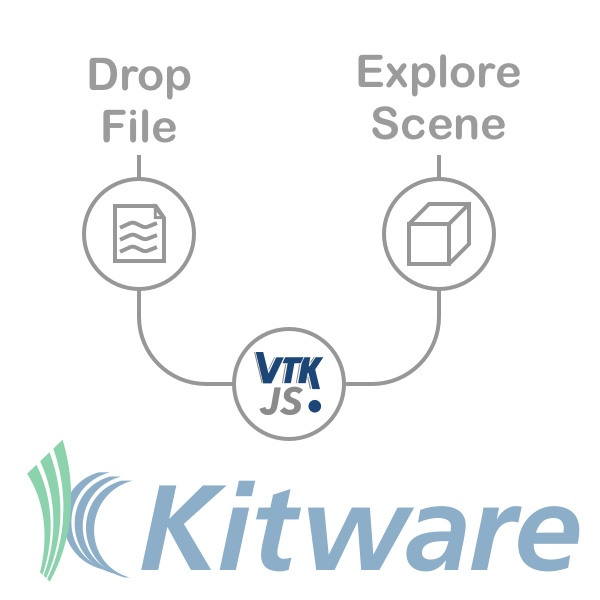

  FE spaces: ND dofs = 29424, H1 dofs = 12090, total = 41514
  Essential DOFs: ND = 452, H1 = 453, total = 905
  Solving eigenvalue problem (omega = 1, sigma = -5.28, size = 41514)...
  Found 8 modes:
    Mode 1: kn = +2.09668519e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +1.75594546e+00 -0.00000000e+00j
    Mode 3: kn = +1.62618335e+00 -0.00000000e+00j
    Mode 4: kn = +1.53006718e+00 -0.00000000e+00j
    Mode 5: kn = +1.11611961e+00 -0.00000000e+00j
    Mode 6: kn = +1.06782134e+00 -0.00000000e+00j
    Mode 7: kn = +8.56975748e-01 -0.00000000e+00j
    Mode 8: kn = +6.73340532e-01 -0.00000000e+00j
Computed microstrip modes:
  Mode  1: kn= +2.096685 -0.000000j  [bound/hybrid]
  Mode  2: kn= +1.755945 -0.000000j  [bound/hybrid]
  Mode  3: kn= +1.626183 -0.000000j  [bound/hybrid]
  Mode  4: kn= +1.530067 -0.000000j  [bound/hybrid]
  Mode  5: kn= +1.116120 -0.000000j  [bound/hybrid]
  Mode  6: kn= +1.067821 -0.000000j  [bound/hybrid]
  Mode  7: kn= +0.856976 -0.000000j  [radiative

In [5]:
mesh_file = make_microstrip_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    strip_w=1.8,
    strip_t=0.06,
    lc_bulk=0.18,
    lc_strip=0.05,
    meshsize=1.0,  # decrease for convergence checks (e.g. 0.7, 0.5)
)
view_mesh(mesh_file)

mu_inv = {1: 1.0 / mu_r, 2: 1.0 / mu_r}
eps = {1: eps_sub, 2: eps_air}

# WaveguideModeSolver currently supports PEC marking via pec_bdr; it does not
# provide an absorbing boundary-condition model.
pec_bdr = [1, 2]  # ground plane + strip conductor

solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=mu_inv, eps=eps, pec_bdr=pec_bdr)
results = solver.solve(omega, num_modes=8, mode_idx=1)

print("Computed microstrip modes:")
for i, kn in enumerate(results["kn"], start=1):
    if kn_air < kn.real < kn_sub and abs(kn.imag) < 0.1 * abs(kn.real):
        mode_type = "bound/hybrid"
    elif abs(kn.imag) > 0.1 * abs(kn.real):
        mode_type = "evanescent"
    else:
        mode_type = "radiative or box mode"
    print(f"  Mode {i:2d}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j  [{mode_type}]")




MFEM Warning: 18 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



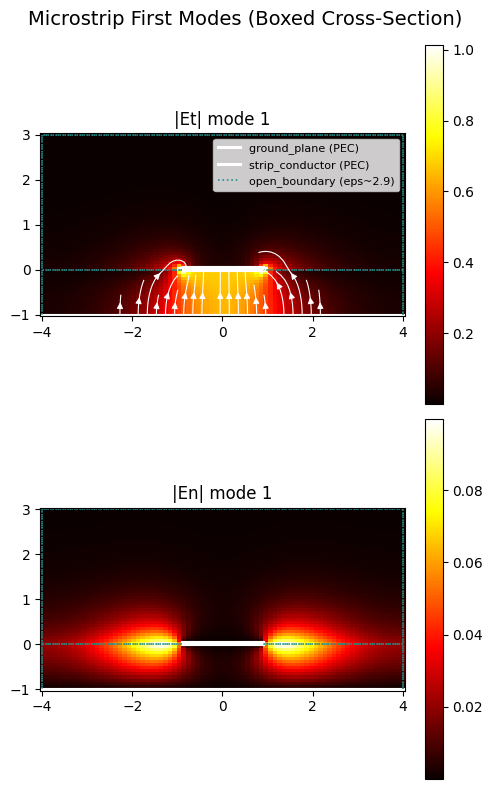

In [6]:
view_fields_2d(
    solver=solver,
    results=results,
    mesh_file=mesh_file,
    eps=eps,
    pec_bdr=pec_bdr,
    include_streamplot=True,
    streamplot_density=1.2,
    streamplot_show_arrows=True,
    streamplot_normalize=True,
    streamplot_seed_from_field=True,
    streamplot_seed_frac=0.1,
    streamplot_seed_stride=2,
    streamplot_mask_weak=True,
    streamplot_min_frac=0.1,
    num_modes=1,
    nx=80,
    ny=60,
    cmap="hot",
    title="Microstrip First Modes (Boxed Cross-Section)",
)

## Validation vs. Hammerstad-Jensen

To validate loss prediction, we compare **transmission magnitude** estimated from solver-derived effective permittivity against a Hammerstad-Jensen-based dielectric-loss model.

Validation sweep setup (kept comfortably inside commonly used validity limits):
- Relative permittivity: $2.2 \le \varepsilon_r \le 6.15$
- Width ratio: $0.8 \le w/h \le 2.5$
- Thin strip: $t/h = 0.04$
- Low-loss dielectric: $\tan\delta = 0.002$

For each case, we compute:
- Solver-derived: run eigenmode with real $\varepsilon_r$, infer $\varepsilon_{\mathrm{eff,solver}}=(\Re\{k_n\}/\omega)^2/\mu_r$, then use low-loss dielectric estimate for $\alpha$
- HJ-based reference: $|S_{21}|_{\mathrm{HJ}} \approx e^{-\alpha_{\mathrm{HJ}}L}$ using $\varepsilon_{\mathrm{eff,HJ}}$ and a quasi-static dielectric filling factor
- Impedance comparison: two numerical estimates are used: (i) contour-based $Z_{0,VI}=|V/I|$ and (ii) quasi-static energy/capacitance estimate $Z_{0,C}$, both compared to analytic $Z_{0,\mathrm{HJ}}$

Low-loss approximation used in this cell:
- For a weakly lossy dielectric, write the propagation constant as $\gamma = \alpha + j\beta$ and use $\varepsilon = \varepsilon'(1-j\tan\delta_{\mathrm{eff}})$ with $\tan\delta_{\mathrm{eff}} \ll 1$.
- First-order expansion gives $\alpha \approx \tfrac{\beta}{2}\tan\delta_{\mathrm{eff}}$.
- In quasi-TEM form, $\beta \approx \omega\sqrt{\mu_r\varepsilon_{\mathrm{eff}}}$.
- We estimate $\tan\delta_{\mathrm{eff}} = q\,\tan\delta$ with filling factor $q \approx (\varepsilon_{\mathrm{eff}}-1)/(\varepsilon_r-1)$.
- Therefore, $\alpha \approx \tfrac{1}{2}\,\omega\sqrt{\mu_r\varepsilon_{\mathrm{eff}}}\,q\tan\delta$ and $|S_{21}| \approx e^{-\alpha L}$.

Note: this eigenmode setup uses PEC conductors and real-valued material tensors, so this section validates **dielectric loss contribution** (not conductor loss).

In [ ]:
def hammerstad_jensen_eps_eff(er, u):
    if u <= 0:
        raise ValueError("u = w/h must be positive")
    a = 1.0 + (1.0 / 49.0) * np.log((u**4 + (u / 52.0) ** 2) / (u**4 + 0.432))
    a += (1.0 / 18.7) * np.log(1.0 + u / 18.1)
    b = 0.564 * ((er - 0.9) / (er + 3.0)) ** 0.053
    return 0.5 * (er + 1.0) + 0.5 * (er - 1.0) * (1.0 + 10.0 / u) ** (-a * b)


def hj_dielectric_alpha(omega, er, eeff, tand):
    # Quasi-static electric energy filling in substrate.
    q = (eeff - 1.0) / max(er - 1.0, 1e-12)
    tand_eff = q * tand
    beta_hj = omega * np.sqrt(mu_r * eeff)
    # Low-loss approximation for attenuation constant.
    return 0.5 * beta_hj * tand_eff


def hammerstad_jensen_z0(er, u):
    eeff = hammerstad_jensen_eps_eff(er, u)
    f = 6.0 + (2.0 * np.pi - 6.0) * np.exp(-((30.666 / u) ** 0.7528))
    return (60.0 / np.sqrt(eeff)) * np.log(f / u + np.sqrt(1.0 + (2.0 / u) ** 2))


def pick_guided_mode(kn_vals, omega, mu_r, eps_air, eps_sub):
    k_air = omega * np.sqrt(mu_r * eps_air)
    k_sub = omega * np.sqrt(mu_r * eps_sub)
    guided = [
        kn for kn in kn_vals
        if (k_air * 1.001) < kn.real < (k_sub * 0.999) and abs(kn.imag) < 0.05 * max(abs(kn.real), 1e-12)
    ]
    if guided:
        return sorted(guided, key=lambda z: z.real)[-1]
    return sorted(kn_vals, key=lambda z: abs(z.imag))[0]


def _mode_vectors_from_kn(results, kn_target, solver):
    idx = int(np.argmin(np.abs(results["kn"] - kn_target)))
    e_vec = results["eigenvectors_raw"][:, idx]
    et = e_vec[:solver.nd_size]
    en = e_vec[solver.nd_size:]
    en_phys = en / (1j * kn_target)
    return et, en_phys


def _bilinear_sample(X, Y, F, xq, yq):
    xs = X[0, :]
    ys = Y[:, 0]
    if xq < xs[0] or xq > xs[-1] or yq < ys[0] or yq > ys[-1]:
        return np.nan + 1j * np.nan
    i = int(np.clip(np.searchsorted(xs, xq) - 1, 0, len(xs) - 2))
    j = int(np.clip(np.searchsorted(ys, yq) - 1, 0, len(ys) - 2))
    x1, x2 = xs[i], xs[i + 1]
    y1, y2 = ys[j], ys[j + 1]
    tx = 0.0 if x2 == x1 else (xq - x1) / (x2 - x1)
    ty = 0.0 if y2 == y1 else (yq - y1) / (y2 - y1)
    f11 = F[j, i]
    f21 = F[j, i + 1]
    f12 = F[j + 1, i]
    f22 = F[j + 1, i + 1]
    return (
        (1 - tx) * (1 - ty) * f11
        + tx * (1 - ty) * f21
        + (1 - tx) * ty * f12
        + tx * ty * f22
    )


def estimate_vi_impedance(X, Y, Ex, Ey, Ez, kn_mode, omega, mu_r, strip_w, strip_t, h_sub):
    # Voltage: line integral of Ey from ground toward strip centerline.
    x0 = 0.0
    y0 = -h_sub + 0.02 * h_sub
    y1 = -0.02 * h_sub
    ys = np.linspace(y0, y1, 400)
    ey_line = np.array([_bilinear_sample(X, Y, Ey, x0, yy) for yy in ys])
    ey_line = np.nan_to_num(ey_line, nan=0.0, posinf=0.0, neginf=0.0)
    V = np.trapezoid(ey_line, ys)

    # Reconstruct Ht from curl(E) relations for exp(-j kn z) convention.
    dEz_dy, dEz_dx = np.gradient(Ez, Y[:, 0], X[0, :], edge_order=2)
    Hx = (1j / (omega * mu_r)) * dEz_dy - (kn_mode / (omega * mu_r)) * Ey
    Hy = (kn_mode / (omega * mu_r)) * Ex - (1j / (omega * mu_r)) * dEz_dx

    # Current: Ampere loop integral around strip on a small rectangular contour.
    dx = float(np.mean(np.diff(X[0, :])))
    dy = float(np.mean(np.diff(Y[:, 0])))
    pad = max(2.0 * max(dx, dy), 0.04 * h_sub)
    xl = -strip_w / 2 - pad
    xr = +strip_w / 2 + pad
    yb = -pad
    yt = strip_t + pad
    nseg = 300

    xt = np.linspace(xl, xr, nseg)
    xb = np.linspace(xr, xl, nseg)
    yr = np.linspace(yt, yb, nseg)
    yl = np.linspace(yb, yt, nseg)

    top_s = np.nan_to_num(np.array([_bilinear_sample(X, Y, Hx, xx, yt) for xx in xt]), nan=0.0, posinf=0.0, neginf=0.0)
    right_s = np.nan_to_num(np.array([_bilinear_sample(X, Y, Hy, xr, yy) for yy in yr]), nan=0.0, posinf=0.0, neginf=0.0)
    bot_s = np.nan_to_num(np.array([_bilinear_sample(X, Y, Hx, xx, yb) for xx in xb]), nan=0.0, posinf=0.0, neginf=0.0)
    left_s = np.nan_to_num(np.array([_bilinear_sample(X, Y, Hy, xl, yy) for yy in yl]), nan=0.0, posinf=0.0, neginf=0.0)
    top = np.trapezoid(top_s, xt)
    right = np.trapezoid(right_s, yr)
    bot = np.trapezoid(bot_s, xb)
    left = np.trapezoid(left_s, yl)
    I = top + right + bot + left

    z0_vi_norm = abs(V) / max(abs(I), 1e-14)
    return z0_vi_norm, abs(V)


def estimate_capacitance_impedance(X, Y, Ex, Ey, Ez, er, eps_eff_solver, vmag, eta0):
    eps_r = np.where(Y < 0.0, er, 1.0)
    e2 = np.abs(Ex) ** 2 + np.abs(Ey) ** 2 + np.abs(Ez) ** 2
    e2 = np.nan_to_num(e2, nan=0.0, posinf=0.0, neginf=0.0)
    we_density = 0.25 * eps_r * e2
    we = np.trapezoid(np.trapezoid(we_density, X[0, :], axis=1), Y[:, 0])
    vmag = float(np.nan_to_num(vmag, nan=0.0, posinf=0.0, neginf=0.0))
    c_norm = 4.0 * we / max(vmag**2, 1e-14)
    z0_c = eta0 * np.sqrt(max(eps_eff_solver, 1e-12)) / max(c_norm, 1e-14)
    return z0_c


validation_cases = [
    {"eps_sub": 2.2, "w_over_h": 0.8},
    {"eps_sub": 2.2, "w_over_h": 1.6},
    {"eps_sub": 4.4, "w_over_h": 1.0},
    {"eps_sub": 4.4, "w_over_h": 2.0},
    {"eps_sub": 6.15, "w_over_h": 1.2},
    {"eps_sub": 6.15, "w_over_h": 2.5},
]

h_sub_val = 1.0
h_air_val = 3.0
box_w_val = 8.0
strip_t_val = 0.04 * h_sub_val  # t/h = 0.04
tand_sub = 0.002
line_length = 40.0 * h_sub_val
eta0 = 376.730313668
meshsize_val = 1.0

rows = []
for case in validation_cases:
    er = case["eps_sub"]
    u = case["w_over_h"]
    strip_w = u * h_sub_val

    mesh_case = make_microstrip_mesh(
        box_w=box_w_val,
        h_sub=h_sub_val,
        h_air=h_air_val,
        strip_w=strip_w,
        strip_t=strip_t_val,
        lc_bulk=0.18,
        lc_strip=0.05,
        meshsize=meshsize_val,
    )

    eps_case = {1: er, 2: eps_air}
    solver_case = WaveguideModeSolver(mesh_case, order=2, mu_inv=mu_inv, eps=eps_case, pec_bdr=pec_bdr)
    res_case = solver_case.solve(omega, num_modes=8, mode_idx=1)

    kn_pick = pick_guided_mode(res_case["kn"], omega, mu_r, eps_air, er)
    eps_eff_solver = (kn_pick.real / omega) ** 2 / mu_r
    alpha_solver = hj_dielectric_alpha(omega, er, eps_eff_solver, tand_sub)
    s21_solver = np.exp(-alpha_solver * line_length)
    et_mode, en_mode = _mode_vectors_from_kn(res_case, kn_pick, solver_case)
    Xg, Yg, Exg, Eyg, Ezg = solver_case.get_field_on_grid(et_mode, en_mode, nx=120, ny=90)

    eps_eff_hj = hammerstad_jensen_eps_eff(er, u)
    alpha_hj = hj_dielectric_alpha(omega, er, eps_eff_hj, tand_sub)
    s21_hj = np.exp(-alpha_hj * line_length)
    z0_vi_norm, vmag = estimate_vi_impedance(Xg, Yg, Exg, Eyg, Ezg, kn_pick, omega, mu_r, strip_w, strip_t_val, h_sub_val)
    z0_vi = eta0 * z0_vi_norm
    z0_cap = estimate_capacitance_impedance(Xg, Yg, Exg, Eyg, Ezg, er, eps_eff_solver, vmag, eta0)
    z0_hj = hammerstad_jensen_z0(er, u)

    eps_eff_err_pct = 100.0 * (eps_eff_solver - eps_eff_hj) / max(eps_eff_hj, 1e-12)
    err_pct = 100.0 * (s21_solver - s21_hj) / max(s21_hj, 1e-12)
    z0_vi_err_pct = 100.0 * (z0_vi - z0_hj) / max(z0_hj, 1e-12)
    z0_cap_err_pct = 100.0 * (z0_cap - z0_hj) / max(z0_hj, 1e-12)
    il_solver_db = -20.0 * np.log10(max(s21_solver, 1e-14))
    il_hj_db = -20.0 * np.log10(max(s21_hj, 1e-14))
    rows.append((er, u, eps_eff_solver, eps_eff_hj, eps_eff_err_pct, s21_solver, s21_hj, err_pct, z0_vi, z0_cap, z0_hj, z0_vi_err_pct, z0_cap_err_pct, il_solver_db, il_hj_db))

  FE spaces: ND dofs = 29582, H1 dofs = 12128, total = 41710
  Essential DOFs: ND = 368, H1 = 369, total = 737
  Solving eigenvalue problem (omega = 1, sigma = -2.42, size = 41710)...
  Found 8 modes:
    Mode 1: kn = +1.38392529e+00 -0.00000000e+00j <-- selected
    Mode 2: kn = +1.07672619e+00 -0.00000000e+00j
    Mode 3: kn = +1.06539697e+00 -0.00000000e+00j
    Mode 4: kn = +8.62195048e-01 -0.00000000e+00j
    Mode 5: kn = +7.70162648e-01 -0.00000000e+00j
    Mode 6: kn = +4.62361581e-01 -0.00000000e+00j
    Mode 7: kn = +6.17026492e-02 +1.07924361e+00j
    Mode 8: kn = +6.17026492e-02 -1.07924361e+00j


MFEM Warning: 12 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515

  FE spaces: ND dofs = 29474, H1 dofs = 12104, total = 41578
  Essential DOFs: ND = 432, H1 = 433

Validation against Hammerstad-Jensen (dielectric loss via |S21|):
tan(delta)=0.0020, normalized line length L=40.00
  er   w/h   eps_eff_num   eps_eff_HJ  eps_err[%]   |S21|_num   |S21|_HJ   S21_err[%]   Z0_VI[ohm]   Z0_C[ohm]   Z0_HJ[ohm]   Z0_VI_err[%]   Z0_C_err[%]   IL_num[dB]   IL_HJ[dB]
 2.20 0.80     1.915249     1.756003      9.069    0.958658   0.967158      -0.879     125.838        nan     105.120        19.709         nan       0.3667      0.2901
 2.20 1.60     1.994345     1.811757     10.078    0.954271   0.964234      -1.033      91.891        nan      74.765        22.906         nan       0.4066      0.3164
 4.40 1.00     3.847855     3.166083     21.534    0.936391   0.955669      -2.017      97.442        nan      71.100        37.050         nan       0.5709      0.3939
 4.40 2.00     4.054514     3.340487     21.375    0.930197   0.950919      -2.179      66.819        nan      48.745        37.080         nan       0.6285      0.4371
 6.15 1.20     5.520567     4.

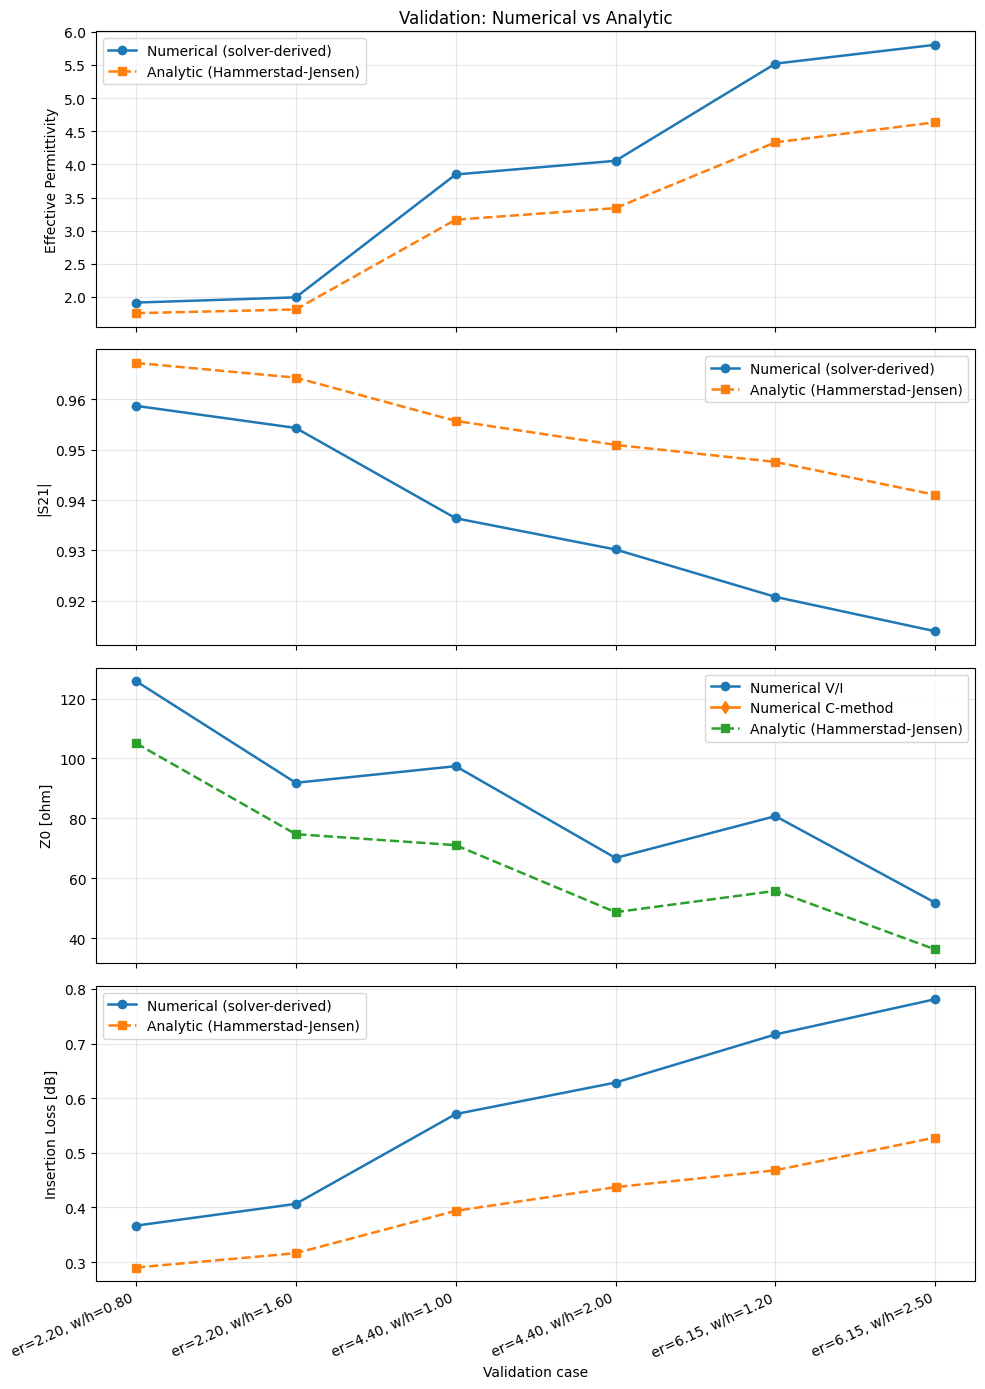

In [10]:
rows = sorted(rows, key=lambda r: (r[0], r[1]))
case_labels = [f"er={r[0]:.2f}, w/h={r[1]:.2f}" for r in rows]
x = np.arange(len(rows))
eps_eff_solver_vals = [r[2] for r in rows]
eps_eff_hj_vals = [r[3] for r in rows]
s21_solver_vals = [r[5] for r in rows]
s21_hj_vals = [r[6] for r in rows]
z0_vi_vals = [r[8] for r in rows]
z0_cap_vals = [r[9] for r in rows]
z0_hj_vals = [r[10] for r in rows]
il_solver_vals = [r[13] for r in rows]
il_hj_vals = [r[14] for r in rows]

print("Validation against Hammerstad-Jensen (dielectric loss via |S21|):")
print(f"tan(delta)={tand_sub:.4f}, normalized line length L={line_length:.2f}")
print("  er   w/h   eps_eff_num   eps_eff_HJ  eps_err[%]   |S21|_num   |S21|_HJ   S21_err[%]   Z0_VI[ohm]   Z0_C[ohm]   Z0_HJ[ohm]   Z0_VI_err[%]   Z0_C_err[%]   IL_num[dB]   IL_HJ[dB]")
for er, u, ee_num, ee_hj, ee_err, s21_s, s21_hj, e_pct, z0_vi_i, z0_c_i, z0_hj_i, z0_e1, z0_e2, il_s, il_hj in rows:
    print(f"{er:5.2f} {u:4.2f} {ee_num:12.6f} {ee_hj:12.6f} {ee_err:10.3f} {s21_s:11.6f} {s21_hj:10.6f} {e_pct:11.3f} {z0_vi_i:11.3f} {z0_c_i:10.3f} {z0_hj_i:11.3f} {z0_e1:13.3f} {z0_e2:11.3f} {il_s:12.4f} {il_hj:11.4f}")

abs_eps_err = [abs(r[4]) for r in rows]
abs_s21_err = [abs(r[7]) for r in rows]
abs_z0_vi_err = [abs(r[11]) for r in rows]
abs_z0_cap_err = [abs(r[12]) for r in rows]
print(f"\nMean |rel err| in eps_eff: {np.mean(abs_eps_err):.3f}%")
print(f"Max  |rel err| in eps_eff: {np.max(abs_eps_err):.3f}%")
print(f"Mean |rel err| in |S21|:  {np.mean(abs_s21_err):.3f}%")
print(f"Max  |rel err| in |S21|:  {np.max(abs_s21_err):.3f}%")
print(f"Mean |rel err| in Z0 (V/I): {np.mean(abs_z0_vi_err):.3f}%")
print(f"Max  |rel err| in Z0 (V/I): {np.max(abs_z0_vi_err):.3f}%")
print(f"Mean |rel err| in Z0 (C):   {np.mean(abs_z0_cap_err):.3f}%")
print(f"Max  |rel err| in Z0 (C):   {np.max(abs_z0_cap_err):.3f}%")

fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
axes[0].plot(x, eps_eff_solver_vals, "o-", lw=1.8, label="Numerical (solver-derived)")
axes[0].plot(x, eps_eff_hj_vals, "s--", lw=1.8, label="Analytic (Hammerstad-Jensen)")
axes[0].set_ylabel("Effective Permittivity")
axes[0].set_title("Validation: Numerical vs Analytic")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, s21_solver_vals, "o-", lw=1.8, label="Numerical (solver-derived)")
axes[1].plot(x, s21_hj_vals, "s--", lw=1.8, label="Analytic (Hammerstad-Jensen)")
axes[1].set_ylabel("|S21|")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(x, z0_vi_vals, "o-", lw=1.8, label="Numerical V/I")
axes[2].plot(x, z0_cap_vals, "d-", lw=1.9, label="Numerical C-method")
axes[2].plot(x, z0_hj_vals, "s--", lw=1.8, label="Analytic (Hammerstad-Jensen)")
axes[2].set_ylabel("Z0 [ohm]")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(x, il_solver_vals, "o-", lw=1.8, label="Numerical (solver-derived)")
axes[3].plot(x, il_hj_vals, "s--", lw=1.8, label="Analytic (Hammerstad-Jensen)")
axes[3].set_ylabel("Insertion Loss [dB]")
axes[3].set_xlabel("Validation case")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[3].set_xticks(x)
axes[3].set_xticklabels(case_labels, rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [12]:
print(z0_vi_vals)
print(z0_cap_vals)

[np.float64(125.83823007021324), np.float64(91.89052781525307), np.float64(97.44207221663675), np.float64(66.81916521950247), np.float64(80.77316329572062), np.float64(51.87959650985845)]
[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
